In [1]:
#librariries 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
plt.style.use('default')

import os
from livelossplot import PlotLossesKerasTF
import tensorflow as tf 
import keras
import cv2
from random import Random as random
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import plot_model
from tensorflow.keras import layers , models, optimizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.models import Model,Sequential
from tensorflow.keras.layers import Dense, Input, Dropout,Flatten, Conv2D
from tensorflow.keras.layers import BatchNormalization, Activation, MaxPooling2D
from tensorflow.keras.layers import *
from tensorflow.keras.applications import ResNet50V2

In [2]:
#load the dataset
train_dir = '../data/train/'
test_dir= '../data/test/'
os.listdir(train_dir)

['happy',
 '.DS_Store',
 'sad',
 'fear',
 'surprise',
 'neutral',
 'angry',
 'disgust']

In [4]:
#visualizing the image classes
def Class_count(path, name):
    class_dict = {}
    # Ensure the path ends with a separator
    if not path.endswith(os.path.sep):
        path += os.path.sep
    
    # Iterate over directories in the given path
    for c in os.listdir(path):
        full_path = os.path.join(path, c)
        if os.path.isdir(full_path):  # Check if it's a directory
            class_dict[c] = len(os.listdir(full_path))  # Count files in the directory

    # Create a DataFrame
    df = pd.DataFrame(list(class_dict.items()), columns=[name, 'Count'])
    return df


Train_count = Class_count(train_dir, 'image_name').sort_values(by='Count', ascending=False).rename(columns={'Count':'Train_Count'}).reset_index(drop=True)
Test_count = Class_count(test_dir,"image_name").sort_values(by="Count",ascending=False).rename(columns={'Count':'Test_Count'}).reset_index(drop=True)

In [5]:
merged_df=pd.merge(Train_count,Test_count, on= 'image_name')
merged_df.set_index('image_name',inplace=True)
merged_df

,Train_Count,Test_Count
image_name,,
happy,7215,1774
neutral,4965,1233
sad,4830,1247
fear,4097,1024
angry,3995,958
surprise,3171,831
disgust,436,111


<Axes: ylabel='image_name'>

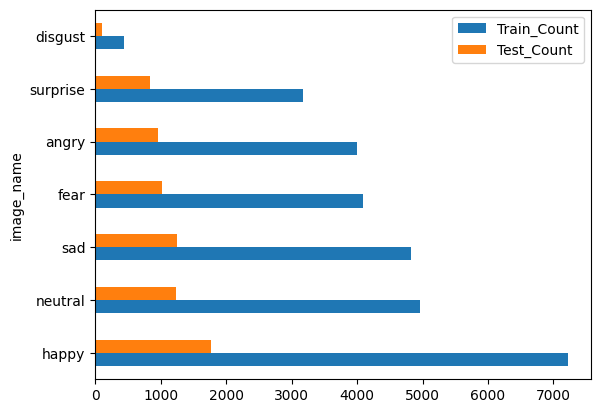

In [6]:
# plotting the image
merged_df.plot(kind='barh')

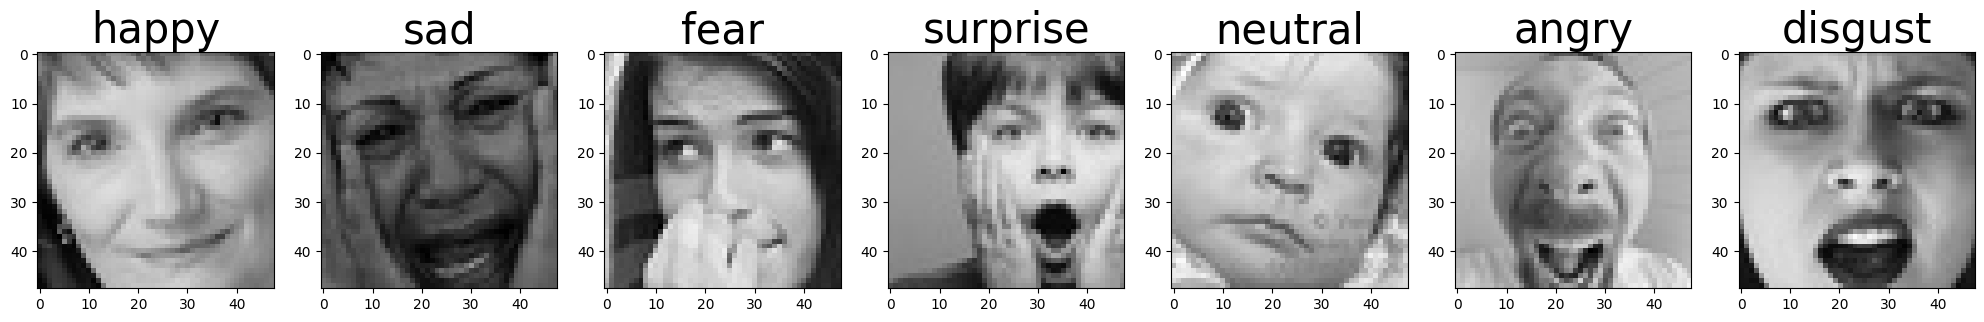

In [7]:
plt.style.use('default')
plt.figure(figsize = (25, 8))
image_count = 1

for directory in os.listdir(train_dir):
    if directory[0] != '.':
        for i, file in enumerate(os.listdir(train_dir+ directory)):
            if i == 1:
                break
            else:
                fig = plt.subplot(1, 7, image_count)
                image_count += 1
                image = cv2.imread(train_dir + directory + '/' + file)
                plt.imshow(image)
                plt.title(directory, fontsize = 30)

In [9]:
img_size = 48
batch_size = 64 # denote the number of image will process in one pass by model
train_preprocessor = ImageDataGenerator(
    rescale = 1/255.,
    #Data Augmentation
    rotation_range = 10,
    zoom_range = 0.2,
    width_shift_range=0.1,
    height_shift_range = 0.1,
    horizontal_flip = True,
    shear_range = 0.1,
    fill_mode = 'nearest',

    
)
test_preprocessor = ImageDataGenerator(rescale=1/255.,
                                    )

train_generator = train_preprocessor.flow_from_directory(
    '../data/train/',
    class_mode = "categorical",
    target_size=(img_size,img_size),
    color_mode='grayscale',
    shuffle=True,
    batch_size=batch_size,
    subset = 'training'
)
test_generator = test_preprocessor.flow_from_directory(
    '../data/test/',
    class_mode = "categorical",
    target_size=(img_size,img_size),
    color_mode='grayscale',
    shuffle=False,
    batch_size=batch_size,
    
)


Found 22968 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


In [15]:
#set seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)
def Create_Model():
    model = tf.keras.Sequential()
    #input layer
    model.add(tf.keras.layers.Input(shape=(48,48,1)))
    #CNN layrers
    model.add(tf.keras.layers.Conv2D(32,(3,3),strides=(1,1), padding='same'))
    model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.Activation('relu'))
    model.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 2)))
    model.add(tf.keras.layers.Dropout(0.25))
    
    model.add(tf.keras.layers.Conv2D(64,(3,3),strides=(1,1), padding='same'))
    model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.Activation('relu'))
    model.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 2)))
    model.add(tf.keras.layers.Dropout(0.25))

    model.add(tf.keras.layers.Conv2D(128,(3,3),strides=(1,1), padding='same'))
    model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.Activation('relu'))
    model.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 2)))
    model.add(tf.keras.layers.Dropout(0.25))

    model.add(tf.keras.layers.Conv2D(256,(3,3),strides=(1,1), padding='same'))
    model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.Activation('relu'))
    model.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 2)))
    model.add(tf.keras.layers.Dropout(0.25))

    model.add(tf.keras.layers.Conv2D(512,(3,3),strides=(1,1), padding='same'))
    model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.Activation('relu'))
    model.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 2)))
    model.add(tf.keras.layers.Dropout(0.25))

    model.add(tf.keras.layers.Flatten())
    
    model.add(tf.keras.layers.Dense(1024,kernel_regularizer=l2(0.001)))
    model.add(tf.keras.layers.BatchNormalization())
    model.add(Activation('relu'))
    model.add(Dropout(0.25))

    model.add(tf.keras.layers.Dense(512,kernel_regularizer=l2(0.001)))
    model.add(tf.keras.layers.BatchNormalization())
    model.add(Activation('relu'))
    model.add(Dropout(0.25))

    model.add(tf.keras.layers.Dense(256,kernel_regularizer=l2(0.001)))
    model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.Activation('relu'))
    model.add(tf.keras.layers.Dropout(0.25))

    model.add(tf.keras.layers.Dense(7, activation='softmax'))
    return model 


In [16]:
from tensorflow.keras.metrics import Precision, Recall
from sklearn.metrics import f1_score

precision = Precision()
recall = Recall()

In [17]:
CNN_Model = Create_Model()
CNN_Model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy',precision,recall])
CNN_Model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 6, 6, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 6, 6, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 3, 3, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 3, 3, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 2,762,375 (10.54 MB)

 Trainable params: 2,756,807 (10.52 MB)

 Non-trainable params: 5,568 (21.75 KB)

In [14]:
# Create Callback Checkpoint
checkpoint_path = "CNN_Model_Checkpoint.keras"

Checkpoint = ModelCheckpoint(checkpoint_path, monitor="val_accuracy", save_best_only=True,mode='max')

# Create Early Stopping Callback to monitor the accuracy
#Early_Stopping = EarlyStopping(monitor = 'val_accuracy', patience = 20, restore_best_weights = True, verbose=1)

# Create ReduceLROnPlateau Callback to reduce overfitting by decreasing learning rate
Reducing_LR = ReduceLROnPlateau(monitor='val_loss', factor=0.25, patience=7, mode='auto', min_lr=1e-7,verbose=1)



callbacks = [Checkpoint, Reducing_LR]
steps_per_epoch = train_generator.n // train_generator.batch_size
validation_steps = test_generator.n // test_generator.batch_size

In [15]:
history = CNN_Model.fit(
    x=train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=60,
    validation_data = test_generator,
    validation_steps = validation_steps,
    callbacks=callbacks,
)

Epoch 1/60


/opt/homebrew/anaconda3/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


448/448 ━━━━━━━━━━━━━━━━━━━━ 142s 309ms/step - accuracy: 0.2114 - loss: 3.5981 - precision: 0.2104 - recall: 0.0221 - val_accuracy: 0.2499 - val_loss: 2.8286 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/60
448/448 ━━━━━━━━━━━━━━━━━━━━ 0s 149us/step - accuracy: 0.2656 - loss: 2.7072 - precision: 1.0000 - recall: 0.0312 - val_accuracy: 0.0000e+00 - val_loss: 3.8868 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/60


2024-09-23 06:39:09.601976: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
/opt/homebrew/anaconda3/lib/python3.12/contextlib.py:158: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(value)
2024-09-23 06:39:09.629446: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


448/448 ━━━━━━━━━━━━━━━━━━━━ 138s 308ms/step - accuracy: 0.2668 - loss: 2.5889 - precision: 0.3481 - recall: 0.0200 - val_accuracy: 0.2817 - val_loss: 2.5639 - val_precision: 0.3015 - val_recall: 0.2331 - learning_rate: 0.0010
Epoch 4/60
448/448 ━━━━━━━━━━━━━━━━━━━━ 0s 97us/step - accuracy: 0.4219 - loss: 1.9845 - precision: 0.6250 - recall: 0.1562 - val_accuracy: 0.1000 - val_loss: 3.2106 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 5/60


...

448/448 ━━━━━━━━━━━━━━━━━━━━ 139s 309ms/step - accuracy: 0.4418 - loss: 1.5505 - precision: 0.7113 - recall: 0.2005 - val_accuracy: 0.4831 - val_loss: 1.4614 - val_precision: 0.7417 - val_recall: 0.2547 - learning_rate: 0.0010
Epoch 10/60
448/448 ━━━━━━━━━━━━━━━━━━━━ 0s 138us/step - accuracy: 0.4531 - loss: 1.5142 - precision: 0.7917 - recall: 0.2969 - val_accuracy: 0.8000 - val_loss: 1.1722 - val_precision: 1.0000 - val_recall: 0.5000 - learning_rate: 0.0010
Epoch 11/60
448/448 ━━━━━━━━━━━━━━━━━━━━ 140s 312ms/step - accuracy: 0.4448 - loss: 1.5197 - precision: 0.6999 - recall: 0.2109 - val_accuracy: 0.4577 - val_loss: 1.4530 - val_precision: 0.8045 - val_recall: 0.2176 - learning_rate: 0.0010
Epoch 12/60
448/448 ━━━━━━━━━━━━━━━━━━━━ 0s 137us/step - accuracy: 0.4062 - loss: 1.5346 - precision: 0.7368 - recall: 0.2188 - val_accuracy: 0.9000 - val_loss: 0.8416 - val_precision: 1.0000 - val_recall: 0.5000 - learning_rate: 0.0010
Epoch 13/60
448/448 ━━━━━━━━━━━━━━━━━━━━ 142s 317ms/step - a

2024-09-23 06:55:30.235875: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


448/448 ━━━━━━━━━━━━━━━━━━━━ 141s 315ms/step - accuracy: 0.4848 - loss: 1.4627 - precision: 0.7265 - recall: 0.2483 - val_accuracy: 0.5364 - val_loss: 1.3235 - val_precision: 0.7566 - val_recall: 0.3278 - learning_rate: 0.0010
Epoch 18/60
448/448 ━━━━━━━━━━━━━━━━━━━━ 0s 130us/step - accuracy: 0.5312 - loss: 1.2526 - precision: 0.7000 - recall: 0.3281 - val_accuracy: 0.9000 - val_loss: 0.8218 - val_precision: 1.0000 - val_recall: 0.7000 - learning_rate: 0.0010
Epoch 19/60
448/448 ━━━━━━━━━━━━━━━━━━━━ 142s 317ms/step - accuracy: 0.4977 - loss: 1.4288 - precision: 0.7167 - recall: 0.2679 - val_accuracy: 0.4894 - val_loss: 1.4735 - val_precision: 0.6996 - val_recall: 0.2437 - learning_rate: 0.0010
Epoch 20/60
448/448 ━━━━━━━━━━━━━━━━━━━━ 0s 388us/step - accuracy: 0.5625 - loss: 1.3089 - precision: 0.7200 - recall: 0.2812 - val_accuracy: 1.0000 - val_loss: 0.2740 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 21/60
448/448 ━━━━━━━━━━━━━━━━━━━━ 140s 312ms/step - a

2024-09-23 07:14:37.083621: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


448/448 ━━━━━━━━━━━━━━━━━━━━ 139s 310ms/step - accuracy: 0.5462 - loss: 1.2584 - precision: 0.7369 - recall: 0.3507 - val_accuracy: 0.5868 - val_loss: 1.1315 - val_precision: 0.7427 - val_recall: 0.4346 - learning_rate: 2.5000e-04
Epoch 34/60
  1/448 ━━━━━━━━━━━━━━━━━━━━ 1:57 263ms/step - accuracy: 0.5312 - loss: 1.2527 - precision: 0.7500 - recall: 0.3750
Epoch 34: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
448/448 ━━━━━━━━━━━━━━━━━━━━ 0s 118us/step - accuracy: 0.5312 - loss: 1.2527 - precision: 0.7500 - recall: 0.3750 - val_accuracy: 1.0000 - val_loss: 0.3257 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 2.5000e-04
Epoch 35/60
448/448 ━━━━━━━━━━━━━━━━━━━━ 139s 311ms/step - accuracy: 0.5487 - loss: 1.2421 - precision: 0.7407 - recall: 0.3543 - val_accuracy: 0.5894 - val_loss: 1.1090 - val_precision: 0.7580 - val_recall: 0.4270 - learning_rate: 6.2500e-05
Epoch 36/60
448/448 ━━━━━━━━━━━━━━━━━━━━ 0s 144us/step - accuracy: 0.5469 - loss: 1.3327 - pr

In [16]:
CNN_Score = CNN_Model.evaluate(test_generator)
final_accuracy = history.history['accuracy'][-1]

print("Test Loss     : {:.5f}".format(CNN_Score[0]))
print("Test Accuracy : {:.2f}%".format(CNN_Score[1] * 100))
print("Final Accuracy        : {:.2%}".format(final_accuracy))

113/113 ━━━━━━━━━━━━━━━━━━━━ 8s 66ms/step - accuracy: 0.5364 - loss: 1.1933 - precision: 0.6748 - recall: 0.3840
Test Loss     : 1.05065
Test Accuracy : 60.56%
Final Accuracy        : 51.56%


In [17]:
CNN_predictions = CNN_Model.predict(test_generator)
CNN_predictions = np.argmax(CNN_predictions, axis = 1)

113/113 ━━━━━━━━━━━━━━━━━━━━ 7s 65ms/step


In [18]:
train_generator.class_indices

{'angry': 0,
 'disgust': 1,
 'fear': 2,
 'happy': 3,
 'neutral': 4,
 'sad': 5,
 'surprise': 6}

Text(0.5, 1.0, 'Confusion matrix of model ')

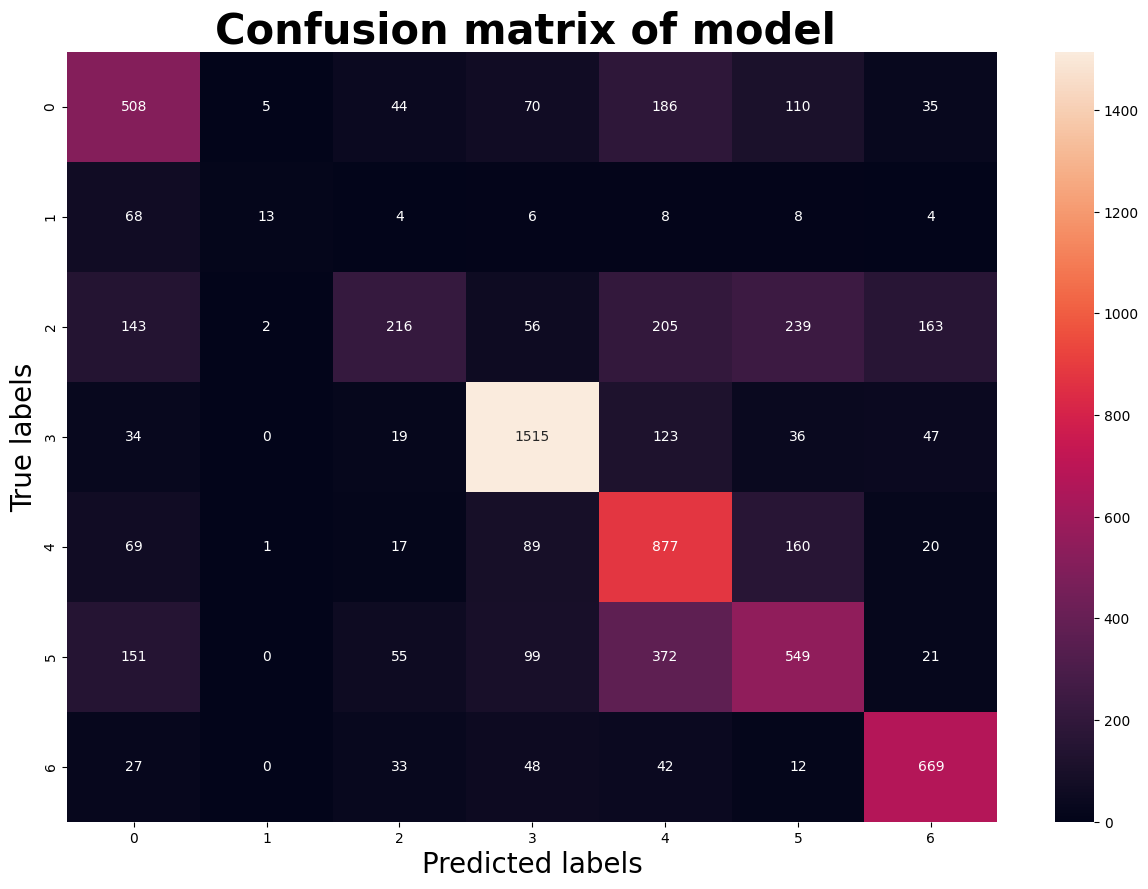

In [19]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
fig,ax = plt.subplots(figsize=(15,10))
conf = confusion_matrix(test_generator.labels, CNN_predictions)
sns.heatmap(conf,annot = True, fmt = 'g', ax = ax)
ax.set_xlabel('Predicted labels', fontsize = 20)
ax.set_ylabel('True labels', fontsize = 20)
ax.set_title('Confusion matrix of model ', fontsize = 30, fontweight = 'bold')


In [23]:
Emotion_Classes = ['Angry', 
                  'Disgust', 
                  'Fear', 
                  'Happy', 
                  'Neutral', 
                  'Sad', 
                  'Surprise']

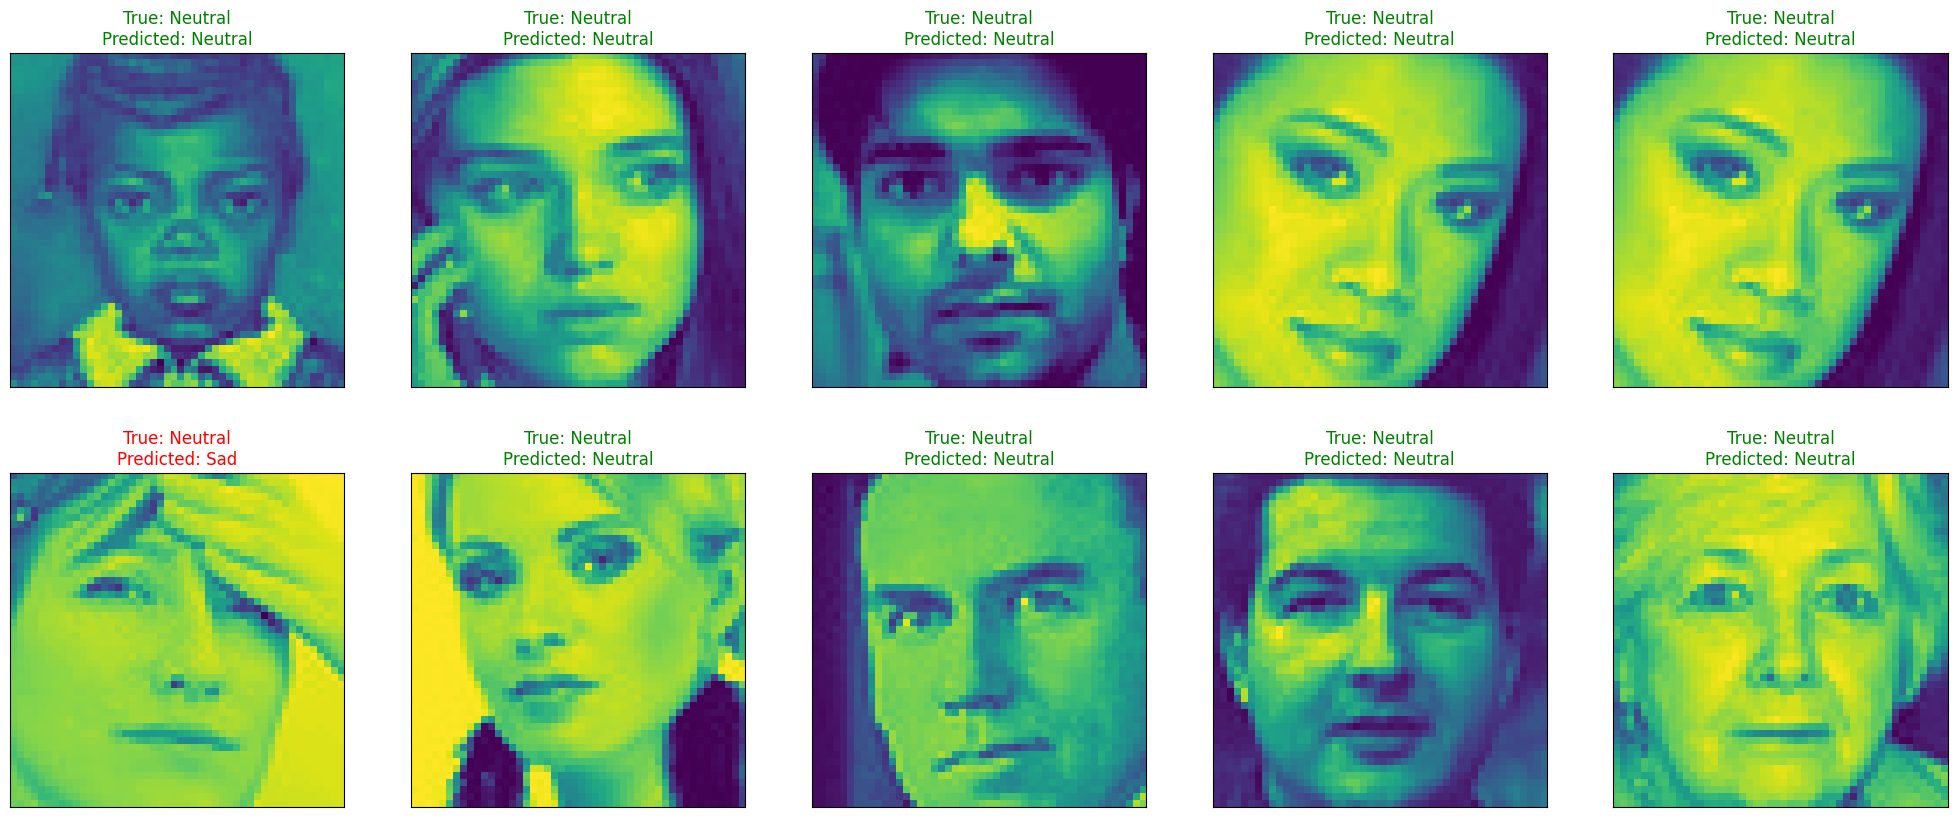

<Figure size 640x480 with 0 Axes>

In [25]:
Random_batch = np.random.randint(0, len(test_generator) - 1)

Random_Img_Index = np.random.randint(0, batch_size - 1 , 10)

fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(25, 10),
                        subplot_kw={'xticks': [], 'yticks': []})

for i, ax in enumerate(axes.flat):

    Random_Img = test_generator[Random_batch][0][Random_Img_Index[i]]

    Random_Img_Label = np.argmax(test_generator[Random_batch][1][Random_Img_Index[i]])

    CNN_predictions = np.argmax(CNN_Model.predict( tf.expand_dims(Random_Img, axis=0) , verbose=0))

    ax.imshow(Random_Img)

    if Emotion_Classes[Random_Img_Label] == Emotion_Classes[CNN_predictions]:
          color = "green"
    else:
          color = "red"
    ax.set_title(f"True: {Emotion_Classes[Random_Img_Label]}\nPredicted: {Emotion_Classes[CNN_predictions]}", color=color)
plt.show()
plt.tight_layout()

In [27]:
model_json = CNN_Model.to_json()
with open("model.json", "w") as json_file:
    json_file.write(model_json)

In [20]:
### model with early_stopping

In [7]:
img_size = 48
batch_size = 32 # denote the number of image will process in one pass by model
train_preprocessor = ImageDataGenerator(
    rescale = 1/255.,
    #Data Augmentation
    rotation_range = 10,
    zoom_range = 0.2,
    width_shift_range=0.1,
    height_shift_range = 0.1,
    horizontal_flip = True,
    shear_range = 0.1,
    fill_mode = 'nearest',
    validation_split=0.2
    
)
test_preprocessor = ImageDataGenerator(rescale=1/255.,
                                    )

train_generator = train_preprocessor.flow_from_directory(
    '../data/train/',
    class_mode = "categorical",
    target_size=(img_size,img_size),
    color_mode='grayscale',
    shuffle=True,
    batch_size=batch_size,
    subset = 'training',
    
)
validation_generator = train_preprocessor.flow_from_directory(
    '../data/train/',
    class_mode = "categorical",
    target_size=(img_size,img_size),
    color_mode='grayscale',
    shuffle=True,
    batch_size=batch_size,
    subset='validation'
)
test_generator = test_preprocessor.flow_from_directory(
    '../data/test/',
    class_mode = "categorical",
    target_size=(img_size,img_size),
    color_mode='grayscale',
    shuffle=False,
    batch_size=batch_size,
    
)


Found 22968 images belonging to 7 classes.
Found 5741 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


In [8]:
#set seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)
def Create_Model():
    model = tf.keras.Sequential()
    #input layer
    model.add(tf.keras.layers.Input(shape=(48,48,1)))
    #CNN layrers 
    model.add(tf.keras.layers.Conv2D(64,(3,3),strides=(1,1), padding='same'))
    model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.Activation('relu'))
    model.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 2)))
    model.add(tf.keras.layers.Dropout(0.25))

    model.add(tf.keras.layers.Conv2D(128,(3,3),strides=(1,1), padding='same'))
    model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.Activation('relu'))
    model.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 2)))
    model.add(tf.keras.layers.Dropout(0.25))

    model.add(tf.keras.layers.Conv2D(256,(3,3),strides=(1,1), padding='same'))
    model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.Activation('relu'))
    model.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 2)))
    model.add(tf.keras.layers.Dropout(0.25))

    model.add(tf.keras.layers.Conv2D(512,(3,3),strides=(1,1), padding='same'))
    model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.Activation('relu'))
    model.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 2)))
    model.add(tf.keras.layers.Dropout(0.25))

    model.add(tf.keras.layers.Flatten())
    
    model.add(tf.keras.layers.Dense(1024,kernel_regularizer=l2(0.001)))
    model.add(tf.keras.layers.BatchNormalization())
    model.add(Activation('relu'))
    model.add(Dropout(0.25))

    model.add(tf.keras.layers.Dense(512,kernel_regularizer=l2(0.001)))
    model.add(tf.keras.layers.BatchNormalization())
    model.add(Activation('relu'))
    model.add(Dropout(0.25))


    model.add(tf.keras.layers.Dense(7, activation='softmax'))
    return model 


In [9]:
model = Create_Model()
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 48, 48, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 6, 6, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1024)           │     4,719,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 1024)           │         4,09

 Total params: 6,807,815 (25.97 MB)

 Trainable params: 6,802,823 (25.95 MB)

 Non-trainable params: 4,992 (19.50 KB)

In [10]:
from tensorflow.keras.metrics import Precision, Recall
from sklearn.metrics import f1_score

precision = Precision()
recall = Recall()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy',precision,recall])

In [13]:
# Create Callback Checkpoint
checkpoint_path = "CNN_Model_Checkpoint.keras"

Checkpoint = ModelCheckpoint(checkpoint_path, monitor="val_accuracy", save_best_only=True,mode='max')

# Create Early Stopping Callback to monitor the accuracy
Early_Stopping = EarlyStopping(monitor = 'val_accuracy', patience = 11, restore_best_weights = True, verbose=1, min_delta=0.00005)

# Create ReduceLROnPlateau Callback to reduce overfitting by decreasing learning rate
Reducing_LR = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, mode='auto', min_lr=1e-7,verbose=1)



callbacks = [PlotLossesKerasTF(),Early_Stopping, Reducing_LR]
steps_per_epoch = train_generator.n // train_generator.batch_size
validation_steps = validation_generator.n // validation_generator.batch_size

In [14]:
print(steps_per_epoch)
print(validation_steps)

717
179


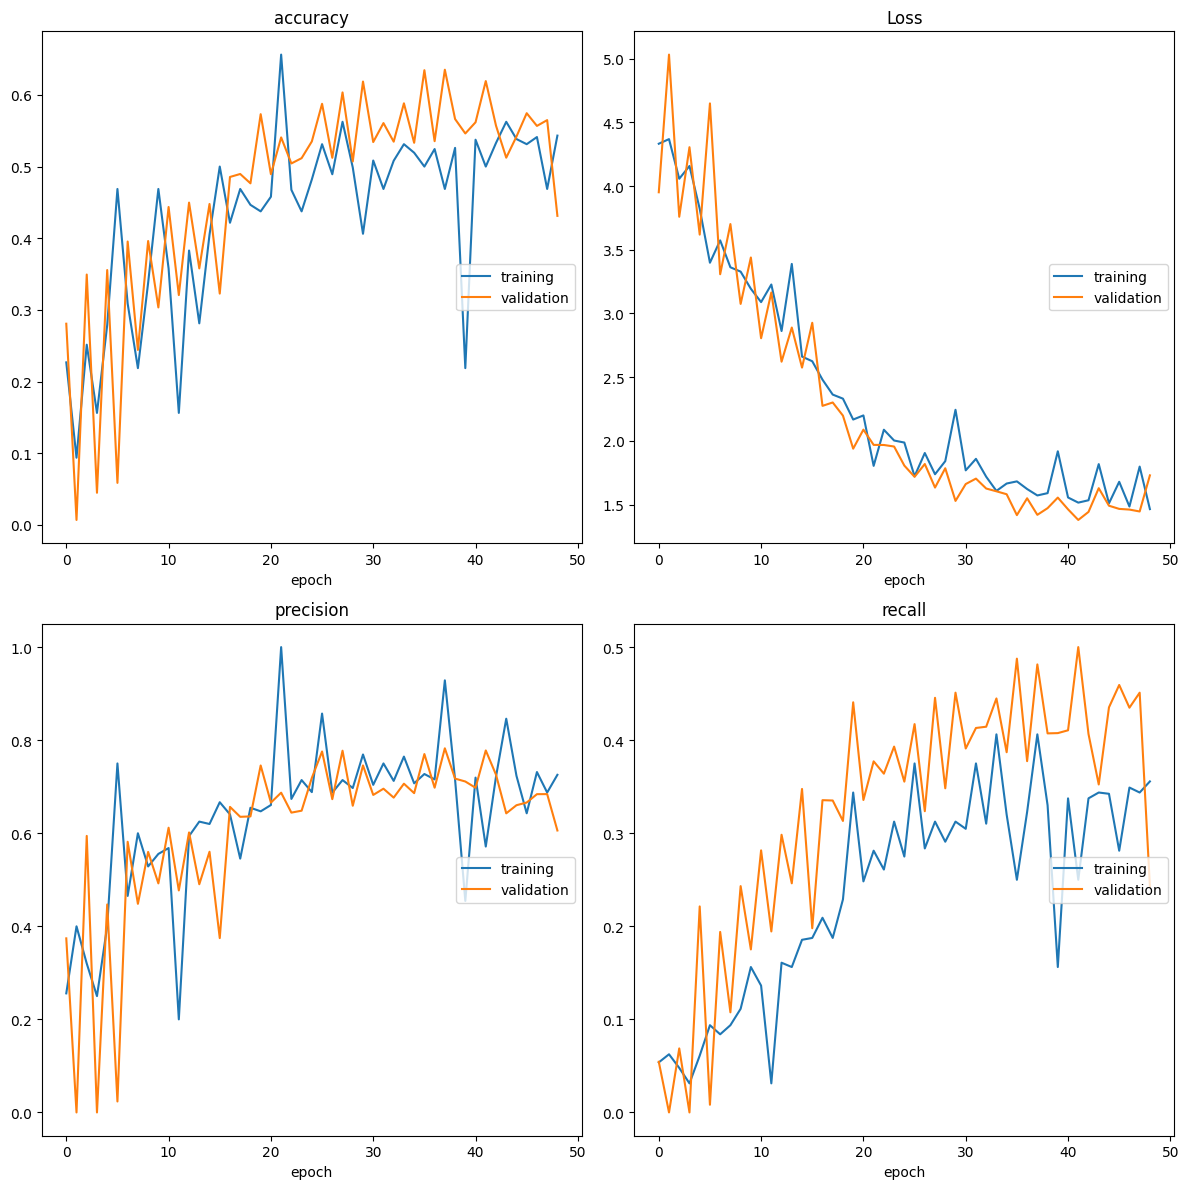

accuracy
	training         	 (min:    0.094, max:    0.656, cur:    0.543)
	validation       	 (min:    0.007, max:    0.635, cur:    0.431)
Loss
	training         	 (min:    1.464, max:    4.369, cur:    1.464)
	validation       	 (min:    1.379, max:    5.032, cur:    1.729)
precision
	training         	 (min:    0.200, max:    1.000, cur:    0.726)
	validation       	 (min:    0.000, max:    0.783, cur:    0.606)
recall
	training         	 (min:    0.031, max:    0.406, cur:    0.356)
	validation       	 (min:    0.000, max:    0.500, cur:    0.243)

Epoch 49: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
717/717 ━━━━━━━━━━━━━━━━━━━━ 275s 384ms/step - accuracy: 0.5418 - loss: 1.4751 - precision: 0.7221 - recall: 0.3505 - val_accuracy: 0.4312 - val_loss: 1.7288 - val_precision: 0.6059 - val_recall: 0.2432 - learning_rate: 1.0000e-04
Epoch 49: early stopping
Restoring model weights from the end of the best epoch: 38.


In [15]:
Model_History = model.fit(
    x=train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=100,
    validation_data = test_generator,
    validation_steps = validation_steps,
    callbacks=callbacks,
)

In [20]:
CNN_Score = model.evaluate(test_generator)
final_accuracy = Model_History.history['accuracy'][-1]

print("Test Loss     : {:.5f}".format(CNN_Score[0]))
print("Test Accuracy : {:.2f}%".format(CNN_Score[1] * 100))
print("Final Accuracy        : {:.2%}".format(final_accuracy))

225/225 ━━━━━━━━━━━━━━━━━━━━ 19s 86ms/step - accuracy: 0.4517 - loss: 1.7397 - precision: 0.5928 - recall: 0.3077
Test Loss     : 1.52145
Test Accuracy : 55.54%
Final Accuracy        : 54.32%


In [21]:
CNN_predictions = model.predict(test_generator)
CNN_predictions = np.argmax(CNN_predictions, axis = 1)

225/225 ━━━━━━━━━━━━━━━━━━━━ 20s 87ms/step


Text(0.5, 1.0, 'Confusion matrix of model ')

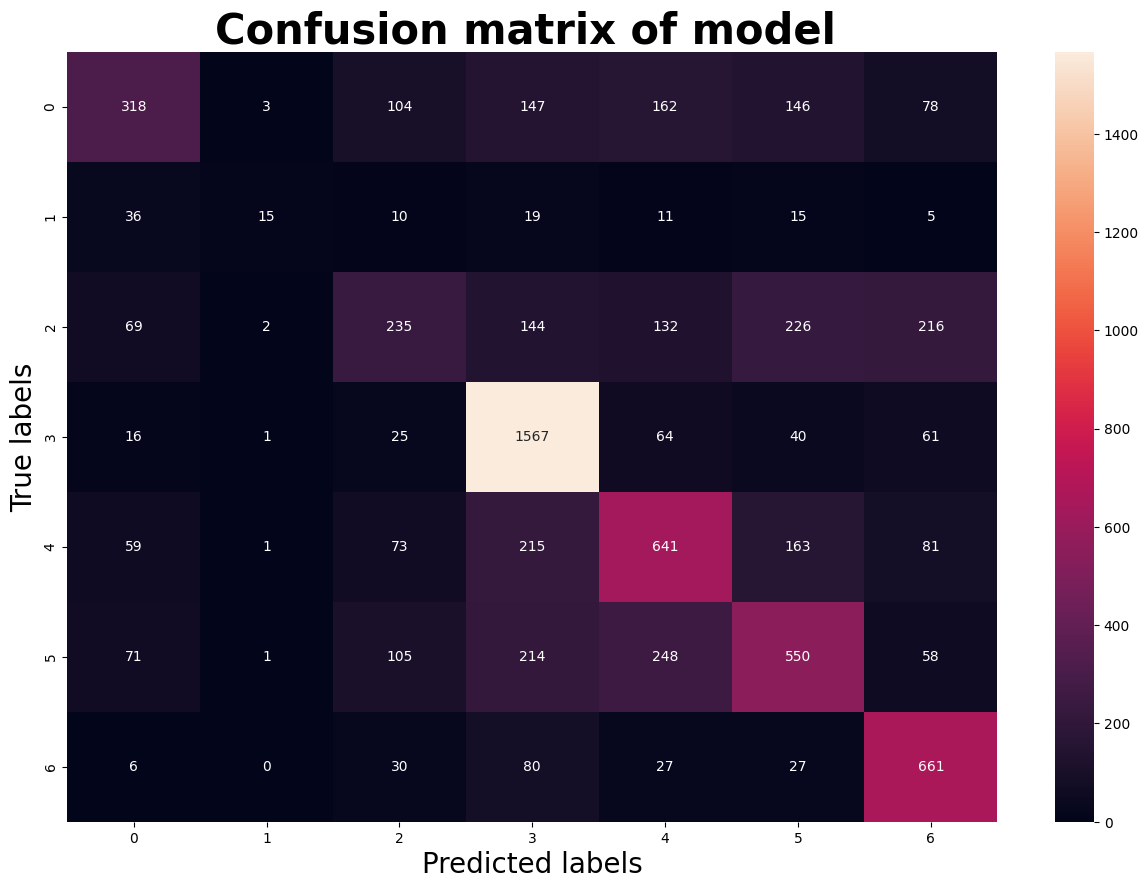

In [22]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
fig,ax = plt.subplots(figsize=(15,10))
conf = confusion_matrix(test_generator.labels, CNN_predictions)
sns.heatmap(conf,annot = True, fmt = 'g', ax = ax)
ax.set_xlabel('Predicted labels', fontsize = 20)
ax.set_ylabel('True labels', fontsize = 20)
ax.set_title('Confusion matrix of model ', fontsize = 30, fontweight = 'bold')

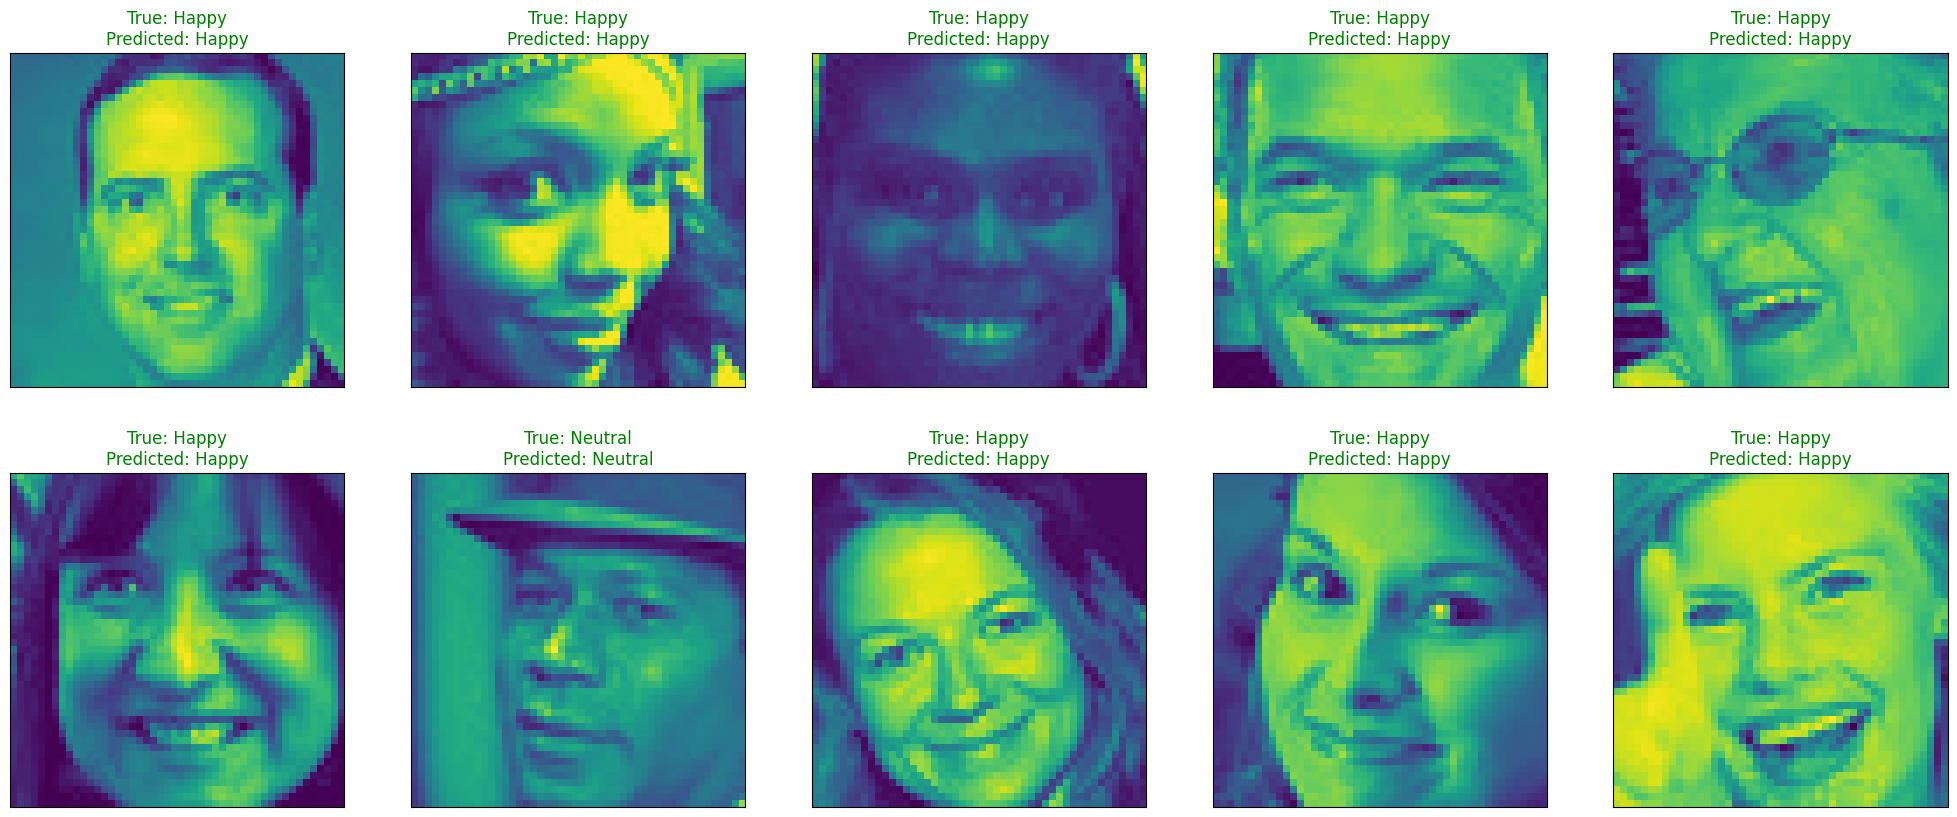

<Figure size 640x480 with 0 Axes>

In [27]:
Random_batch = np.random.randint(0, len(test_generator) - 1)

Random_Img_Index = np.random.randint(0, batch_size - 1 , 10)

fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(25, 10),
                        subplot_kw={'xticks': [], 'yticks': []})

for i, ax in enumerate(axes.flat):

    Random_Img = test_generator[Random_batch][0][Random_Img_Index[i]]

    Random_Img_Label = np.argmax(test_generator[Random_batch][1][Random_Img_Index[i]])

    CNN_predictions = np.argmax(model.predict( tf.expand_dims(Random_Img, axis=0) , verbose=0))

    ax.imshow(Random_Img)

    if Emotion_Classes[Random_Img_Label] == Emotion_Classes[CNN_predictions]:
          color = "green"
    else:
          color = "red"
    ax.set_title(f"True: {Emotion_Classes[Random_Img_Label]}\nPredicted: {Emotion_Classes[CNN_predictions]}", color=color)
plt.show()
plt.tight_layout()

In [ ]:
model.save("Model54.h5")
